In [1]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
print(df.shape)

(50000, 2)


In [3]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [4]:
df.sample(5)

,review,sentiment
37604,Depardieu's most notorious film is this (1974)...,positive
21731,"Well, I can once and for all put an end to the...",negative
39207,This was one of the best shows ever made for T...,positive
6150,It's a mystery to me as to why I haven't caugh...,positive
4503,The fact that a film is on DVD doesn't guarant...,negative


In [6]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


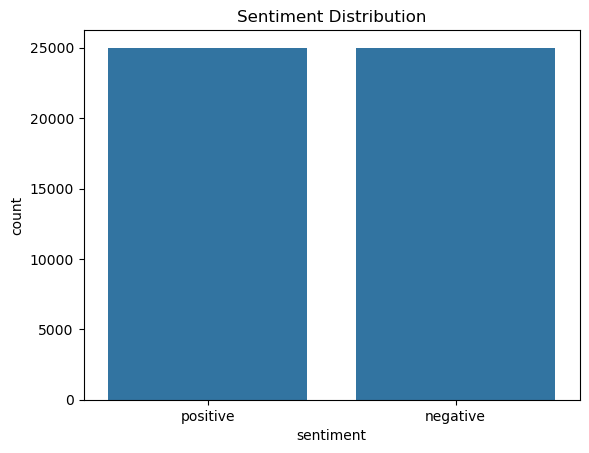

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [9]:
df.sample(5)

,review,sentiment
22786,"An interesting idea for a film, both showing t...",negative
8262,Uneven Bollywood drama. Karisma Kapoor is exce...,positive
24007,I saw this movie at the 18th Haifa film festiv...,positive
45127,Tromaville High has become an amoral wasteland...,negative
17453,While watching this movie I was frustrated and...,positive


In [10]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
# Download required resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# Cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    return " ".join(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...


In [12]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
df['clean_review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [17]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,NaN,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,NaN,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,NaN,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,NaN,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",NaN,petter matteis love time money visually stunni...


In [18]:
from sklearn.model_selection import train_test_split
X = df['clean_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000,)
Testing data: (10000,)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create TF-IDF object
tfidf = TfidfVectorizer(max_features=5000)
# Fit and transform training data
X_train_tfidf = tfidf.fit_transform(X_train)
# Transform testing data
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (40000, 5000)
TF-IDF Testing Shape: (10000, 5000)


In [20]:
from sklearn.feature_extraction.text import CountVectorizer
# Create Bag of Words
bow = CountVectorizer(max_features=5000)
# Fit and transform
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print("BoW Training Shape:", X_train_bow.shape)
print("BoW Testing Shape:", X_test_bow.shape)

BoW Training Shape: (40000, 5000)
BoW Testing Shape: (10000, 5000)


In [21]:
from sklearn.linear_model import LogisticRegression
# Create model
lr = LogisticRegression(max_iter=1000)
# Train model
lr.fit(X_train_tfidf, y_train)
# Predict test data
y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Model Trained Successfully")

ValueError: Input y contains NaN.

In [22]:
print(df['sentiment'].unique())

[nan]


In [23]:
print(df['sentiment'].isnull().sum())

50000


In [24]:
print(df['clean_review'].isnull().sum())

0


In [25]:
# Reload dataset again (important)
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")
# Check unique values
print(df['sentiment'].unique())

['positive' 'negative']


In [26]:
df['sentiment'] = df['sentiment'].replace({
    'positive': 1,
    'negative': 0
})
print(df['sentiment'].unique())

[1 0]


C:\Users\amare\AppData\Local\Temp\ipykernel_3124\140447757.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({


In [28]:
df['clean_review'] = df['review'].apply(clean_text)
print("Cleaning Completed")

Cleaning Completed


In [29]:
from sklearn.model_selection import train_test_split
X = df['clean_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (40000,)
Testing: (10000,)


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF Created Successfully")

TF-IDF Created Successfully


In [31]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Done ✅")

Logistic Regression Done ✅


In [32]:
from sklearn.naive_bayes import MultinomialNB
# Create model
nb = MultinomialNB()
# Train model
nb.fit(X_train_tfidf, y_train)
# Make predictions
y_pred_nb = nb.predict(X_test_tfidf)
print("Naive Bayes Model Trained Successfully ✅")

Naive Bayes Model Trained Successfully ✅


In [33]:
from sklearn.tree import DecisionTreeClassifier
# Create model
dt = DecisionTreeClassifier()
# Train model
dt.fit(X_train_tfidf, y_train)
# Predict
y_pred_dt = dt.predict(X_test_tfidf)
print("Decision Tree Model Trained Successfully ✅")

Decision Tree Model Trained Successfully ✅


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate(y_test, y_pred, model_name):
    print("\n", model_name)
    print("Accuracy:",
          accuracy_score(y_test, y_pred))
    print("Precision:",
          precision_score(y_test, y_pred))
    print("Recall:",
          recall_score(y_test, y_pred))
    print("F1 Score:",
          f1_score(y_test, y_pred))

In [35]:
evaluate(y_test, y_pred_lr,
         "Logistic Regression")
evaluate(y_test, y_pred_nb,
         "Naive Bayes")
evaluate(y_test, y_pred_dt,
         "Decision Tree")


 Logistic Regression
Accuracy: 0.8848
Precision: 0.8764284330815417
Recall: 0.8979956340543759
F1 Score: 0.8870809645167614

 Naive Bayes
Accuracy: 0.8518
Precision: 0.8511352418558736
Recall: 0.8555268902560031
F1 Score: 0.8533254156769596

 Decision Tree
Accuracy: 0.7139
Precision: 0.7205346294046172
Recall: 0.706092478666402
F1 Score: 0.7132404530419966


In [36]:
print("Model Comparison Summary:")
print("Logistic Regression performed best in most cases.")
print("Naive Bayes trained fastest.")
print("Decision Tree had lower accuracy due to overfitting.")

Model Comparison Summary:
Logistic Regression performed best in most cases.
Naive Bayes trained fastest.
Decision Tree had lower accuracy due to overfitting.


from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_rf,
               "Random Forest")

Conclusion
In this project, a complete NLP pipeline was implemented for sentiment analysis.
Steps performed:
- Data preprocessing including tokenization, stopword removal, and lemmatization.
- Feature extraction using Bag of Words and TF-IDF.
- Model training using Logistic Regression, Naive Bayes, and Decision Tree.
- Model evaluation using Accuracy, Precision, Recall, and F1 Score.
Among all models, Logistic Regression with TF-IDF gave the best performance.
This project demonstrated how raw text data can be transformed into meaningful insights using NLP and Machine Learning.